In [2]:
import numpy as np

from fbpinns.problems import BurgersEquation2D
from fbpinns.domains import RectangularDomainND
from fbpinns.decompositions import RectangularDecompositionND
from fbpinns.constants import Constants
from fbpinns.networks import FCN, AdaptiveFCN
from fbpinns.constants import Constants
from fbpinns.trainers import FBPINNTrainer, PINNTrainer
from fbpinns.schedulers import AllActiveSchedulerND, LineSchedulerRectangularND, RandomSubdomainScheduler

from fbpinns.optimisers import lbfgs

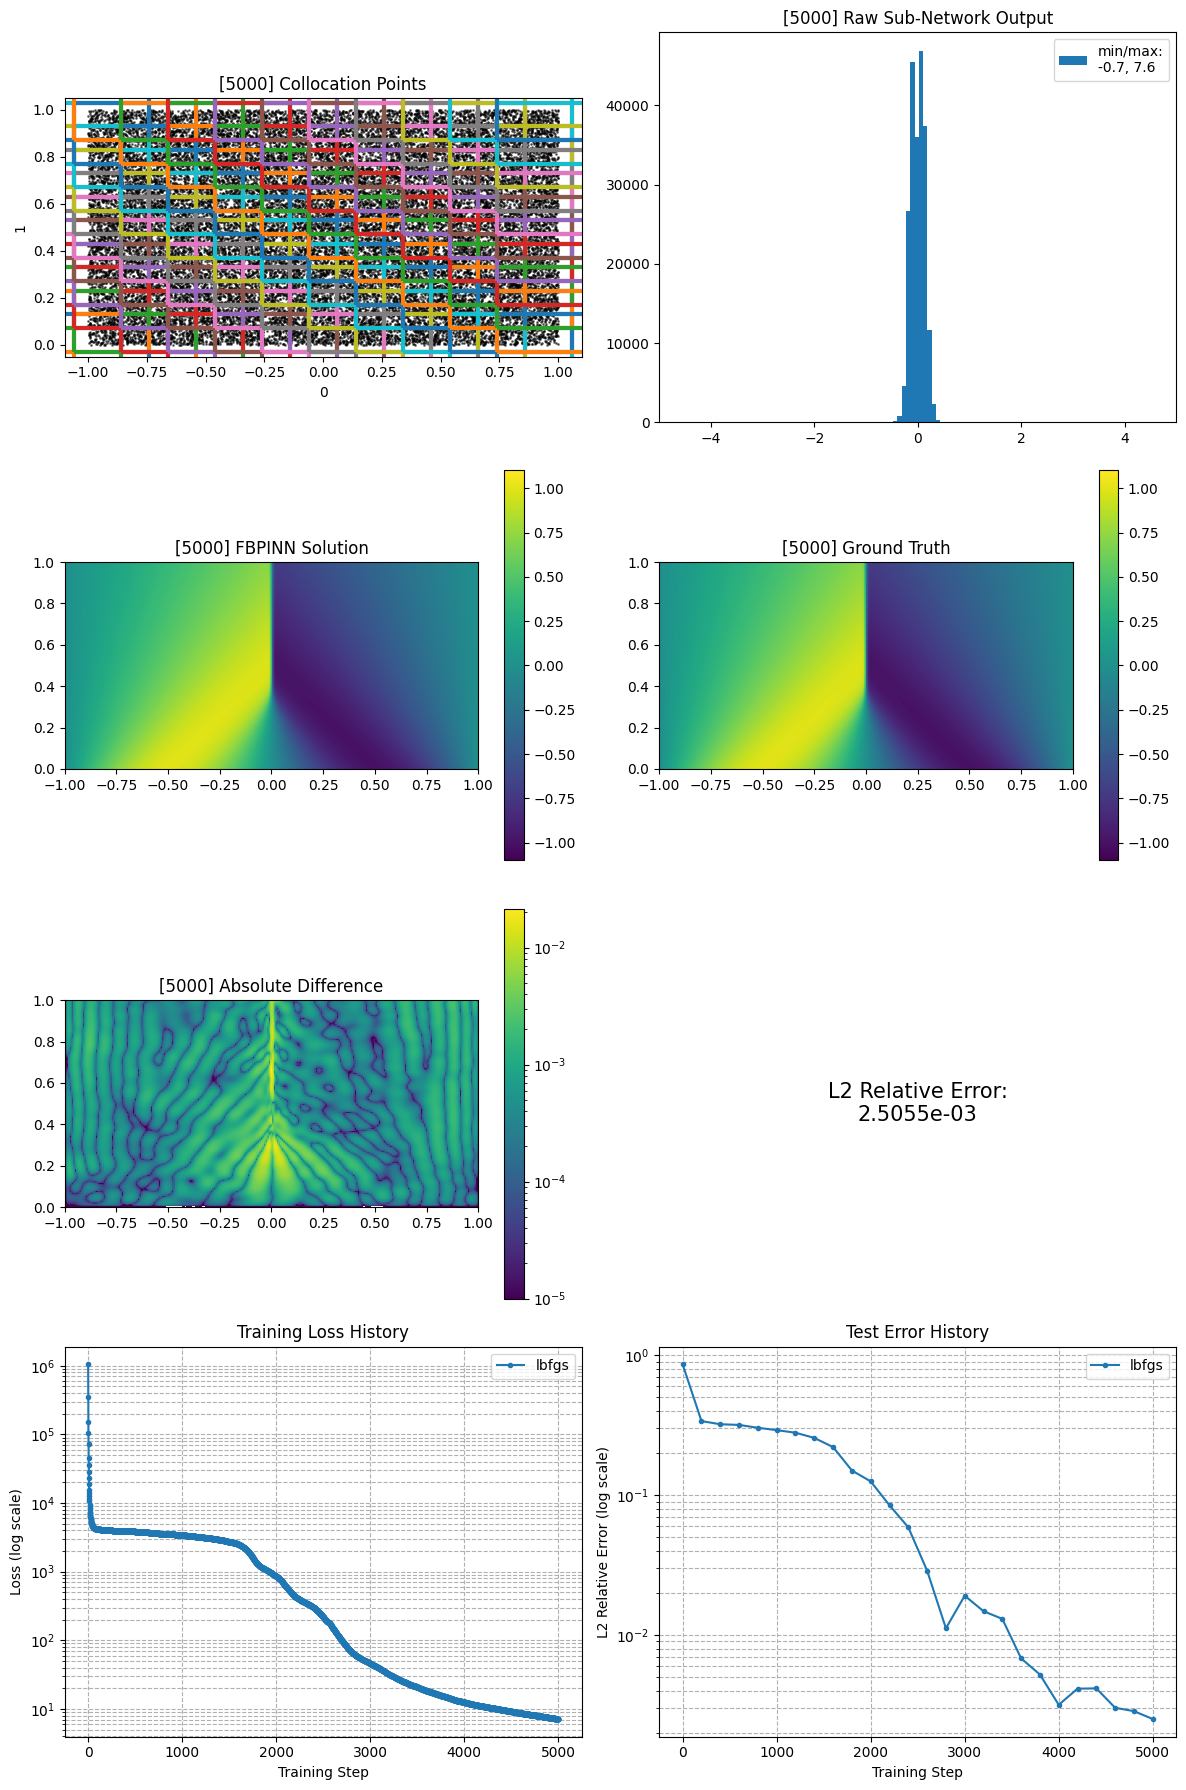

[INFO] 2025-07-03 21:52:35 - [i: 5000/5000] Training complete


In [6]:
XMIN, XMAX, TMIN, TMAX = -1, 1, 0, 1

# subdomain_xs=[np.array([XMIN + XMAX / 2]), np.array([TMIN + TMAX / 2])]
# subdomain_ws=[
#     np.array([2 * (XMAX - XMIN)]),
#     np.array([2 * (TMAX - TMIN)]),
# ]

subdomain_width = 2.6
subdomain_xs=[np.linspace(XMIN, XMAX, 11), np.linspace(TMIN, TMAX, 11)]
subdomain_ws=[
    np.array([subdomain_width * (XMAX - XMIN) / (len(subdomain_xs[0]) - 1),] * len(subdomain_xs[0])),
    np.array([subdomain_width * (TMAX - TMIN) / (len(subdomain_xs[1]) - 1),] * len(subdomain_xs[1])),
]

c = Constants(
    domain=RectangularDomainND,
    domain_init_kwargs = dict(
        xmin=np.array([XMIN, TMIN]),
        xmax=np.array([XMAX, TMAX])
    ),
    
    decomposition=RectangularDecompositionND,
    decomposition_init_kwargs=dict(
        subdomain_xs=subdomain_xs,
        subdomain_ws=subdomain_ws,
        unnorm=(0.,3.),
    ),
    
    problem=BurgersEquation2D,
    problem_init_kwargs = dict(
    ),
    
    network=FCN,
    network_init_kwargs = dict(
        layer_sizes = (2, 16, 16, 1),
    ),
    
    ns=((256, 128),),
    sampler="latinhypercube",
    
    n_test=(256, 128),
    test_freq=1000 / 5,
    clear_output=True,
    
    training_schedule = [
        [
            (AllActiveSchedulerND, dict()),
            (lbfgs, 5000, dict(memory_size=128))
        ],
    ]
)

run = FBPINNTrainer(c)
all_params = run.train()